In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

sys.path.append("../src")

from matrix_factorization import train_matrix_factorization


DATA_PATH = Path("../data/raw/ml-100k")

ratings = pd.read_csv(
    DATA_PATH / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [2]:
train_val, test = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

train, validation = train_test_split(
    train_val,
    test_size=0.125,
    random_state=42
)

print("Training:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Training: 70000
Validation: 10000
Test: 20000


In [3]:
user_ids = sorted(ratings["user_id"].unique())
movie_ids = sorted(ratings["movie_id"].unique())

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_ids)
}

num_users = len(user_ids)
num_movies = len(movie_ids)

In [4]:
def evaluate_model(
    data,
    P,
    Q,
    user_bias,
    movie_bias,
    global_mean,
    user_to_idx,
    movie_to_idx
):
    predictions = []

    for row in data.itertuples():

        if (
            row.user_id not in user_to_idx
            or row.movie_id not in movie_to_idx
        ):
            prediction = global_mean

        else:
            u = user_to_idx[row.user_id]
            i = movie_to_idx[row.movie_id]

            prediction = (
                global_mean
                + user_bias[u]
                + movie_bias[i]
                + np.dot(P[u], Q[i])
            )

        predictions.append(
            np.clip(prediction, 1, 5)
        )

    rmse = np.sqrt(
        mean_squared_error(
            data["rating"],
            predictions
        )
    )

    mae = mean_absolute_error(
        data["rating"],
        predictions
    )

    return rmse, mae

In [5]:
factor_values = [5, 10, 20, 40, 80]

factor_results = []

for n_factors in factor_values:

    print(f"\nTraining with {n_factors} factors...")

    P, Q, user_bias, movie_bias, global_mean, training_rmse = (
        train_matrix_factorization(
            train=train,
            user_to_idx=user_to_idx,
            movie_to_idx=movie_to_idx,
            num_users=num_users,
            num_movies=num_movies,
            n_factors=n_factors,
            learning_rate=0.005,
            regularization=0.02,
            epochs=20,
            seed=42
        )
    )

    rmse, mae = evaluate_model(
        validation,
        P,
        Q,
        user_bias,
        movie_bias,
        global_mean,
        user_to_idx,
        movie_to_idx
    )

    factor_results.append({
        "Factors": n_factors,
        "Validation RMSE": rmse,
        "Validation MAE": mae
    })


Training with 5 factors...
Epoch  1/20 - Training RMSE: 1.0546
Epoch  2/20 - Training RMSE: 0.9899
Epoch  3/20 - Training RMSE: 0.9665
Epoch  4/20 - Training RMSE: 0.9537
Epoch  5/20 - Training RMSE: 0.9454
Epoch  6/20 - Training RMSE: 0.9394
Epoch  7/20 - Training RMSE: 0.9348
Epoch  8/20 - Training RMSE: 0.9311
Epoch  9/20 - Training RMSE: 0.9280
Epoch 10/20 - Training RMSE: 0.9254
Epoch 11/20 - Training RMSE: 0.9231
Epoch 12/20 - Training RMSE: 0.9209
Epoch 13/20 - Training RMSE: 0.9189
Epoch 14/20 - Training RMSE: 0.9170
Epoch 15/20 - Training RMSE: 0.9151
Epoch 16/20 - Training RMSE: 0.9132
Epoch 17/20 - Training RMSE: 0.9112
Epoch 18/20 - Training RMSE: 0.9091
Epoch 19/20 - Training RMSE: 0.9069
Epoch 20/20 - Training RMSE: 0.9045

Training with 10 factors...
Epoch  1/20 - Training RMSE: 1.0547
Epoch  2/20 - Training RMSE: 0.9896
Epoch  3/20 - Training RMSE: 0.9658
Epoch  4/20 - Training RMSE: 0.9526
Epoch  5/20 - Training RMSE: 0.9439
Epoch  6/20 - Training RMSE: 0.9374
Epoch  

In [6]:
factor_results_df = pd.DataFrame(factor_results)

factor_results_df

,Factors,Validation RMSE,Validation MAE
0,5,0.936065,0.741282
1,10,0.934816,0.739317
2,20,0.936744,0.740905
3,40,0.933274,0.738451
4,80,0.936255,0.739399


In [7]:
best_factor_row = factor_results_df.loc[
    factor_results_df["Validation RMSE"].idxmin()
]

best_factors = int(
    best_factor_row["Factors"]
)

print("Best number of factors:", best_factors)
print(
    "Validation RMSE:",
    round(best_factor_row["Validation RMSE"], 4)
)

Best number of factors: 40
Validation RMSE: 0.9333


In [8]:
regularization_values = [
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
]

reg_results = []

for reg in regularization_values:

    print(f"\nTraining with regularization={reg}...")

    P, Q, user_bias, movie_bias, global_mean, training_rmse = (
        train_matrix_factorization(
            train=train,
            user_to_idx=user_to_idx,
            movie_to_idx=movie_to_idx,
            num_users=num_users,
            num_movies=num_movies,
            n_factors=best_factors,
            learning_rate=0.005,
            regularization=reg,
            epochs=20,
            seed=42
        )
    )

    rmse, mae = evaluate_model(
        validation,
        P,
        Q,
        user_bias,
        movie_bias,
        global_mean,
        user_to_idx,
        movie_to_idx
    )

    reg_results.append({
        "Regularization": reg,
        "Validation RMSE": rmse,
        "Validation MAE": mae
    })


Training with regularization=0.005...
Epoch  1/20 - Training RMSE: 1.0565
Epoch  2/20 - Training RMSE: 0.9881
Epoch  3/20 - Training RMSE: 0.9614
Epoch  4/20 - Training RMSE: 0.9454
Epoch  5/20 - Training RMSE: 0.9337
Epoch  6/20 - Training RMSE: 0.9243
Epoch  7/20 - Training RMSE: 0.9160
Epoch  8/20 - Training RMSE: 0.9084
Epoch  9/20 - Training RMSE: 0.9010
Epoch 10/20 - Training RMSE: 0.8936
Epoch 11/20 - Training RMSE: 0.8860
Epoch 12/20 - Training RMSE: 0.8780
Epoch 13/20 - Training RMSE: 0.8696
Epoch 14/20 - Training RMSE: 0.8605
Epoch 15/20 - Training RMSE: 0.8507
Epoch 16/20 - Training RMSE: 0.8403
Epoch 17/20 - Training RMSE: 0.8291
Epoch 18/20 - Training RMSE: 0.8173
Epoch 19/20 - Training RMSE: 0.8049
Epoch 20/20 - Training RMSE: 0.7921

Training with regularization=0.01...
Epoch  1/20 - Training RMSE: 1.0566
Epoch  2/20 - Training RMSE: 0.9882
Epoch  3/20 - Training RMSE: 0.9616
Epoch  4/20 - Training RMSE: 0.9457
Epoch  5/20 - Training RMSE: 0.9342
Epoch  6/20 - Training 

In [9]:
reg_results_df = pd.DataFrame(reg_results)

reg_results_df

,Regularization,Validation RMSE,Validation MAE
0,0.005,0.936650,0.739921
1,0.010,0.935071,0.739131
2,0.020,0.933274,0.738451
3,0.050,0.933516,0.740151
4,0.100,0.937568,0.745120


In [10]:
best_reg_row = reg_results_df.loc[
    reg_results_df["Validation RMSE"].idxmin()
]

best_regularization = float(
    best_reg_row["Regularization"]
)

print(
    "Best regularization:",
    best_regularization
)

print(
    "Validation RMSE:",
    round(
        best_reg_row["Validation RMSE"],
        4
    )
)

Best regularization: 0.02
Validation RMSE: 0.9333


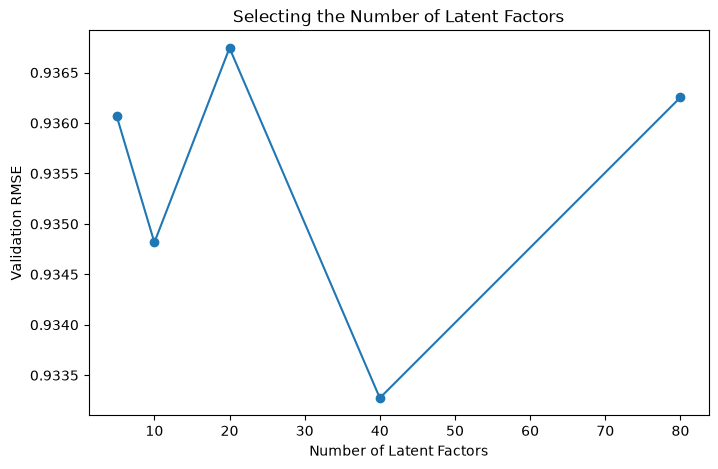

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    factor_results_df["Factors"],
    factor_results_df["Validation RMSE"],
    marker="o"
)

plt.xlabel("Number of Latent Factors")
plt.ylabel("Validation RMSE")
plt.title("Selecting the Number of Latent Factors")

plt.show()

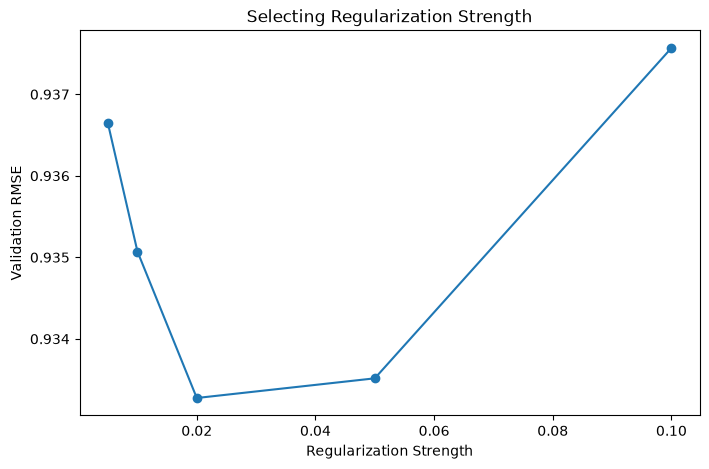

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    reg_results_df["Regularization"],
    reg_results_df["Validation RMSE"],
    marker="o"
)

plt.xlabel("Regularization Strength")
plt.ylabel("Validation RMSE")
plt.title("Selecting Regularization Strength")

plt.show()

In [13]:
final_train = pd.concat(
    [train, validation],
    ignore_index=True
)

print("Final training ratings:", len(final_train))
print("Test ratings:", len(test))

Final training ratings: 80000
Test ratings: 20000


In [14]:
P_final, Q_final, user_bias_final, movie_bias_final, global_mean_final, final_training_rmse = (
    train_matrix_factorization(
        train=final_train,
        user_to_idx=user_to_idx,
        movie_to_idx=movie_to_idx,
        num_users=num_users,
        num_movies=num_movies,
        n_factors=best_factors,
        learning_rate=0.005,
        regularization=best_regularization,
        epochs=20,
        seed=42
    )
)

Epoch  1/20 - Training RMSE: 1.0499
Epoch  2/20 - Training RMSE: 0.9821
Epoch  3/20 - Training RMSE: 0.9571
Epoch  4/20 - Training RMSE: 0.9425
Epoch  5/20 - Training RMSE: 0.9319
Epoch  6/20 - Training RMSE: 0.9235
Epoch  7/20 - Training RMSE: 0.9163
Epoch  8/20 - Training RMSE: 0.9096
Epoch  9/20 - Training RMSE: 0.9034
Epoch 10/20 - Training RMSE: 0.8971
Epoch 11/20 - Training RMSE: 0.8907
Epoch 12/20 - Training RMSE: 0.8841
Epoch 13/20 - Training RMSE: 0.8770
Epoch 14/20 - Training RMSE: 0.8693
Epoch 15/20 - Training RMSE: 0.8611
Epoch 16/20 - Training RMSE: 0.8523
Epoch 17/20 - Training RMSE: 0.8428
Epoch 18/20 - Training RMSE: 0.8327
Epoch 19/20 - Training RMSE: 0.8222
Epoch 20/20 - Training RMSE: 0.8112


In [15]:
final_test_rmse, final_test_mae = evaluate_model(
    test,
    P_final,
    Q_final,
    user_bias_final,
    movie_bias_final,
    global_mean_final,
    user_to_idx,
    movie_to_idx
)

print(f"Final Test RMSE: {final_test_rmse:.4f}")
print(f"Final Test MAE:  {final_test_mae:.4f}")

Final Test RMSE: 0.9343
Final Test MAE:  0.7349


In [16]:
global_predictions = np.full(
    len(test),
    final_train["rating"].mean()
)

global_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        global_predictions
    )
)

global_mae = mean_absolute_error(
    test["rating"],
    global_predictions
)

In [17]:
movie_means = final_train.groupby(
    "movie_id"
)["rating"].mean()

movie_predictions = (
    test["movie_id"]
    .map(movie_means)
    .fillna(final_train["rating"].mean())
)

movie_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        movie_predictions
    )
)

movie_mae = mean_absolute_error(
    test["rating"],
    movie_predictions
)

In [18]:
user_means = final_train.groupby(
    "user_id"
)["rating"].mean()

user_predictions = (
    test["user_id"]
    .map(user_means)
    .fillna(final_train["rating"].mean())
)

user_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        user_predictions
    )
)

user_mae = mean_absolute_error(
    test["rating"],
    user_predictions
)

In [19]:
final_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Movie Mean",
        "User Mean",
        "Matrix Factorization"
    ],
    "RMSE": [
        global_rmse,
        movie_rmse,
        user_rmse,
        final_test_rmse
    ],
    "MAE": [
        global_mae,
        movie_mae,
        user_mae,
        final_test_mae
    ]
})

final_results.sort_values("RMSE")

,Model,RMSE,MAE
3,Matrix Factorization,0.934290,0.734891
1,Movie Mean,1.020964,0.812273
2,User Mean,1.041745,0.834636
0,Global Mean,1.123860,0.941955


In [20]:
def get_top_k_recommendations(user_id, k=10):
    rated_movie_ids = set(
        final_train.loc[
            final_train["user_id"] == user_id,
            "movie_id"
        ]
    )

    candidates = []

    u = user_to_idx[user_id]

    for movie_id in movie_ids:

        if movie_id in rated_movie_ids:
            continue

        i = movie_to_idx[movie_id]

        prediction = (
            global_mean_final
            + user_bias_final[u]
            + movie_bias_final[i]
            + np.dot(P_final[u], Q_final[i])
        )

        candidates.append(
            (movie_id, prediction)
        )

    candidates.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [
        movie_id
        for movie_id, _ in candidates[:k]
    ]

In [21]:
def precision_recall_at_k(k=10, relevance_threshold=4):
    precisions = []
    recalls = []

    for user_id in test["user_id"].unique():

        relevant_movies = set(
            test.loc[
                (test["user_id"] == user_id)
                & (test["rating"] >= relevance_threshold),
                "movie_id"
            ]
        )

        if len(relevant_movies) == 0:
            continue

        recommendations = set(
            get_top_k_recommendations(
                user_id,
                k=k
            )
        )

        hits = len(
            recommendations & relevant_movies
        )

        precision = hits / k

        recall = hits / len(relevant_movies)

        precisions.append(precision)
        recalls.append(recall)

    return (
        np.mean(precisions),
        np.mean(recalls)
    )

In [22]:
precision_10, recall_10 = precision_recall_at_k(
    k=10,
    relevance_threshold=4
)

print(f"Precision@10: {precision_10:.4f}")
print(f"Recall@10:    {recall_10:.4f}")

Precision@10: 0.0674
Recall@10:    0.0448


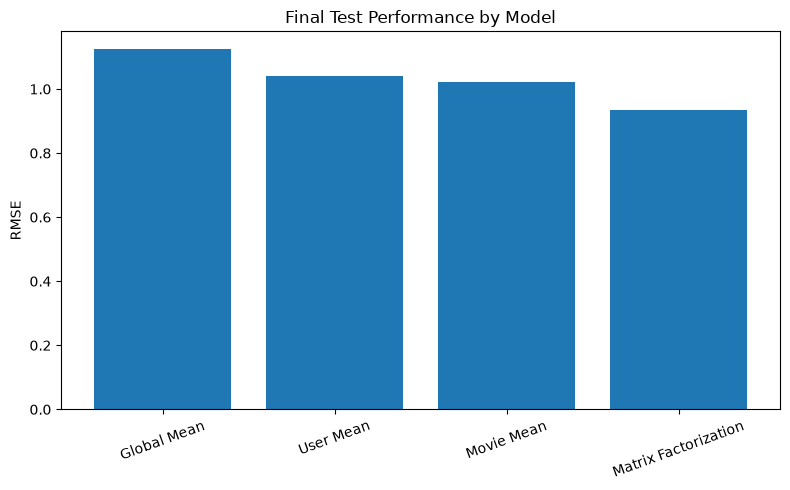

In [23]:
plt.figure(figsize=(8, 5))

sorted_results = final_results.sort_values(
    "RMSE",
    ascending=False
)

plt.bar(
    sorted_results["Model"],
    sorted_results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Final Test Performance by Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Final Evaluation

The final matrix factorization model was selected using a dedicated validation set and evaluated once on the held-out test set.

### Rating Prediction

The final matrix factorization model achieved:

- RMSE: 0.9343
- MAE: 0.7349

This substantially outperformed the Global Mean, User Mean, and Movie Mean baselines.

### Recommendation Ranking

Using ratings of 4 or higher as the relevance threshold, the model achieved:

- Precision@10: 0.0674
- Recall@10: 0.0448

These ranking metrics should be interpreted cautiously. MovieLens contains observed ratings rather than complete information about every movie a user likes. A recommended movie that does not appear as a positive rating in the held-out test set is treated as a non-hit even though the user's true preference for that movie is unknown.

### Conclusion

Matrix factorization successfully learned compact latent representations of users and movies and substantially improved rating prediction compared with simple baseline approaches. Hyperparameters were selected using validation data to prevent test-set leakage, and the final model was evaluated on an untouched test set.

The difference between rating-prediction performance and Top-K ranking performance also demonstrates that accurately predicting ratings and generating effective ranked recommendations are related but distinct objectives.